<a href="https://colab.research.google.com/github/orelebile/PART-C_SPAM_DETECTION_APP/blob/main/PARTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Framing:
People Often tend to click on email links that have malicious intent. Intended to steal their information and demand money in reurn. As a result as a data scientiest a want to develop a model that will be able to classify emails people receive on daily basis. Whether emails are spam or not spam. Those detected as Spam will then be reported as spam. This is essential to guard people's information because this calprits steal information such as financial details such as card number and take money from people's banks, steal their identity for impersonation, steal company information they work at and demand money in return. For a model to be a sucess it shopuld be able to detect spam emails from those that are spam by inputing email messages.

Import Libraries and load data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

df = pd.read_csv('/content/spam.csv', encoding='latin1')

In [15]:
!pip install nltk

Downlaod NLP Resources

In [49]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

 Inspect the Dataset

In [32]:
df.shape #There are 5,572 rows and 5 columns

(5572, 5)

In [13]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [19]:
df.isnull().sum()
#checking for missing data (no missing data)

,0
V1,0
V2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [20]:
df.columns

Index(['V1', 'V2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

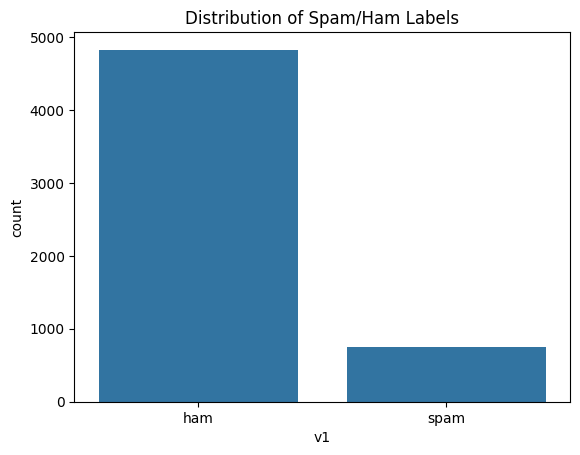

In [35]:
sns.countplot(x="v1", data=df)
plt.title("Distribution of Spam/Ham Labels")
plt.show()

#Interpretation: There are about 4,800 ham emails and 800 spam emails

Explore Example Reviews

In [37]:
print("Sample Ham Review:\n")
print(df[df["v1"] == "ham"]["v2"].iloc[0])

Sample Ham Review:

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [42]:
print("Sample Spam Review:\n")
print(df[df["v1"] == "spam"]["v2"].iloc[0])

Sample Spam Review:

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


In [44]:
df["review_length_chars"] = df["v2"].apply(len)
df["review_length_words"] = df["v2"].apply(lambda x: len(x.split()))
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,review_length_chars,review_length_words
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,20
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,28
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,13


In [45]:
df[["review_length_chars", "review_length_words"]].describe()

,review_length_chars,review_length_words
count,5572.000000,5572.000000
mean,80.118808,15.494436
std,59.690841,11.329427
min,2.000000,1.000000
25%,36.000000,7.000000
50%,61.000000,12.000000
75%,121.000000,23.000000
max,910.000000,171.000000


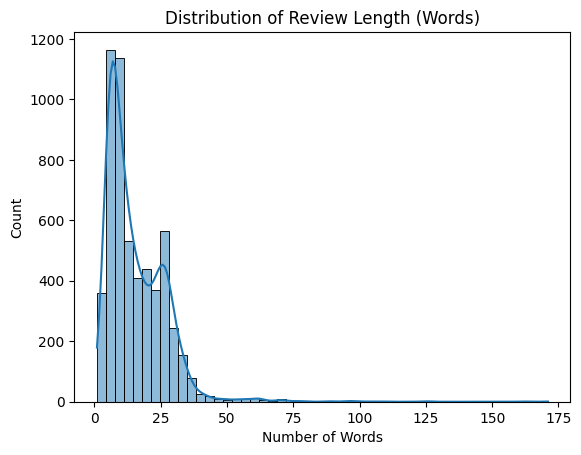

In [46]:
sns.histplot(df["review_length_words"], bins=50, kde=True)
plt.title("Distribution of Review Length (Words)")
plt.xlabel("Number of Words")
plt.show()

Text Cleaning

In [54]:
import re
import string

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra whitespace

    return re.sub(r"\s+", " ", text).strip()

In [55]:
df["clean_review"] = df["v2"].apply(clean_text)
df[["v2", "clean_review"]].head()

,v2,clean_review
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


Comparing Texts

In [57]:
print("Original Review:\n")
print(df["v2"].iloc[0])

print("\n\nCleaned Review:\n")
print(df["clean_review"].iloc[0])

Original Review:

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


Cleaned Review:

go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


Encode Traget Varriables

In [110]:
df["spam_label"] = df["v1"].map({
    "spam": 1,
    "ham": 0
})
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,review_length_chars,review_length_words,clean_review,sentiment_label,sentimental_label,spam_label
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN,161,30,this is the nd time we have tried contact u u ...,1,1,1
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN,37,8,will ì b going to esplanade fr home,0,0,0
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN,57,10,pity was in mood for that soany other suggestions,0,0,0
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN,125,26,the guy did some bitching but i acted like id ...,0,0,0
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN,26,6,rofl its true to its name,0,0,0


In [111]:
X = df["clean_review"]
y = df["spam_label"]

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 4457
Testing set size: 1115


In [114]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")

In [136]:
pip install joblib

In [115]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [116]:
X_train_tfidf.shape

(4457, 7305)

i used Logistic Regression, because it is the most suitable model for binary classifications such as Spam Or Not Spam, Yes Or No, Married or Nor Married.

In [117]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [118]:
y_pred = model.predict(X_test_tfidf)

In [119]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9506726457399103


In [120]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.65      0.78       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



In [121]:
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "NotSpam"

In [123]:
test_review_1 = "his is the 2nd time we have tried 2 contact u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate."
print(predict_sentiment(test_review_1))

Spam


In [128]:
test_review_2 = "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"
print(predict_sentiment(test_review_2))

NotSpam


In [138]:
!python -m pip install joblib

In [91]:
import pickle

# Save the model
with open('Spam Prediction Model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Save the vectorizer
with open('Tfidf Vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

from google.colab import files
files.download('Spam Prediction Model.pkl')
files.download('Tfidf Vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [130]:
!pip install streamlit

In [129]:
import streamlit as st
import pickle
import re
import string

# Define the text cleaning function (copied from previous cells for self-containment)
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Remove extra whitespace
    return re.sub(r"\s+", " ", text).strip()

# Load trained model and vectorizer
try:
    model = pickle.load(open('Spam Prediction Model.pkl', 'rb'))
    vectorizer = pickle.load(open('Tfidf Vectorizer.pkl', 'rb'))
except FileNotFoundError:
    st.error("Error: Model or vectorizer files not found. Please ensure 'Spam Prediction Model.pkl' and 'Tfidf Vectorizer.pkl' are in the correct directory.")
    st.stop() # Stop the app if files are missing

# Define the prediction function
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "NotSpam"

st.title("Spam Email Classification App")

st.write("Enter an email message to classify it as Spam or Not Spam.")

# Text input for the email message
email_message = st.text_area("Email Message", height=150)

# Prediction button
if st.button("Classify Email"):
    if email_message:
        result = predict_sentiment(email_message)
        if result == "Spam":
            st.error(f"Prediction: {result}")
        else:
            st.success(f"Prediction: {result}")
    else:
        st.warning("Please enter an email message to classify.")

2026-03-28 10:38:55.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.549 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.551 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.559 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 10:38:55.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [135]:
# Write the code to app.py
with open("app.py", "w") as f:
    f.write(code)

In [131]:
# Create requirements.txt for the app
with open("requirements.txt", "w") as f:
    f.write("streamlit\n")
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("scikit-learn\n")
    f.write("joblib\n")

Real Life Usage and Improvements

- the application needs to be improved User Interface so that it become visually appealing to users.
- The application can also be used by companies to protect its employees from malicious emails which might in the end harm both the company and employees as these calprits normaly demand money in return (IF THEY HAVE HACKED THE COMPANY`)
- For now the app can only be used for Spam vs Not Spam. it is not flexible